In [3]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

conn = duckdb.connect('../data/database/weather_daily.duckdb')

df = conn.execute("""
SELECT *
FROM raw.weather_daily_historical
""").df()

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)
df.head()

Shape: (7332, 14)

Columns:
 Index(['date', 'city', 'weathercode', 'temperature_2m_max',
       'temperature_2m_min', 'apparent_temperature_max',
       'apparent_temperature_min', 'precipitation_sum', 'precipitation_hours',
       'rain_sum', 'snowfall_sum', 'windspeed_10m_max', 'windgusts_10m_max',
       'winddirection_10m_dominant'],
      dtype='object')

Data types:
 date                          datetime64[us]
city                                  object
weathercode                          float64
temperature_2m_max                   float64
temperature_2m_min                   float64
apparent_temperature_max             float64
apparent_temperature_min             float64
precipitation_sum                    float64
precipitation_hours                  float64
rain_sum                             float64
snowfall_sum                         float64
windspeed_10m_max                    float64
windgusts_10m_max                    float64
winddirection_10m_dominant           fl

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant
0,2021-04-17 20:00:00,Baku,3.0,22.65,10.25,20.987980,8.281424,0.0,0.0,0.0,0.0,22.346113,42.120000,270.581630
1,2021-04-18 20:00:00,Baku,55.0,22.25,12.20,22.634678,9.600903,1.5,3.0,1.5,0.0,19.353138,37.079998,23.838907
2,2021-04-19 20:00:00,Baku,3.0,20.05,11.05,18.579220,10.410341,0.0,0.0,0.0,0.0,26.836306,49.680000,181.429060
3,2021-04-20 20:00:00,Baku,3.0,19.65,14.20,19.307346,9.068678,0.0,0.0,0.0,0.0,35.455887,64.079994,330.248170
4,2021-04-21 20:00:00,Baku,3.0,17.55,12.00,15.577309,7.668547,0.0,0.0,0.0,0.0,33.971867,61.560000,351.265720


#### What this code does

This code connects to a **DuckDB database**, loads historical weather data, and performs an initial **data exploration (EDA setup)**.

---

In [4]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

df.groupby("city").apply(lambda x: x.isnull().mean() * 100)


C:\Users\Asus\AppData\Local\Temp\ipykernel_20168\4111701611.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("city").apply(lambda x: x.isnull().mean() * 100)


,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant
city,,,,,,,,,,,,,,
Baku,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ganja,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Nakhchivan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Shusha,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### What this code does

This code performs a **data quality check** by analyzing missing values in the dataset at both:

- global level (entire dataset)
- city level (grouped analysis)


In [5]:
print(df.describe())

                             date  weathercode  temperature_2m_max  \
count                        7332  7332.000000         7332.000000   
mean   2023-10-20 19:55:17.184942    22.028369           18.444817   
min           2021-04-17 20:00:00     0.000000           -7.803000   
25%           2022-07-19 20:00:00     2.000000           10.050000   
50%           2023-10-20 20:00:00     3.000000           17.950000   
75%           2025-01-20 20:00:00    51.000000           26.600000   
max           2026-04-22 20:00:00    75.000000           42.350000   
std                           NaN    26.931470           10.264764   

       temperature_2m_min  apparent_temperature_max  apparent_temperature_min  \
count         7332.000000               7332.000000               7332.000000   
mean             9.609936                 16.673331                  7.678116   
min            -14.803000                -12.527184                -19.868164   
25%              2.750000                  7.

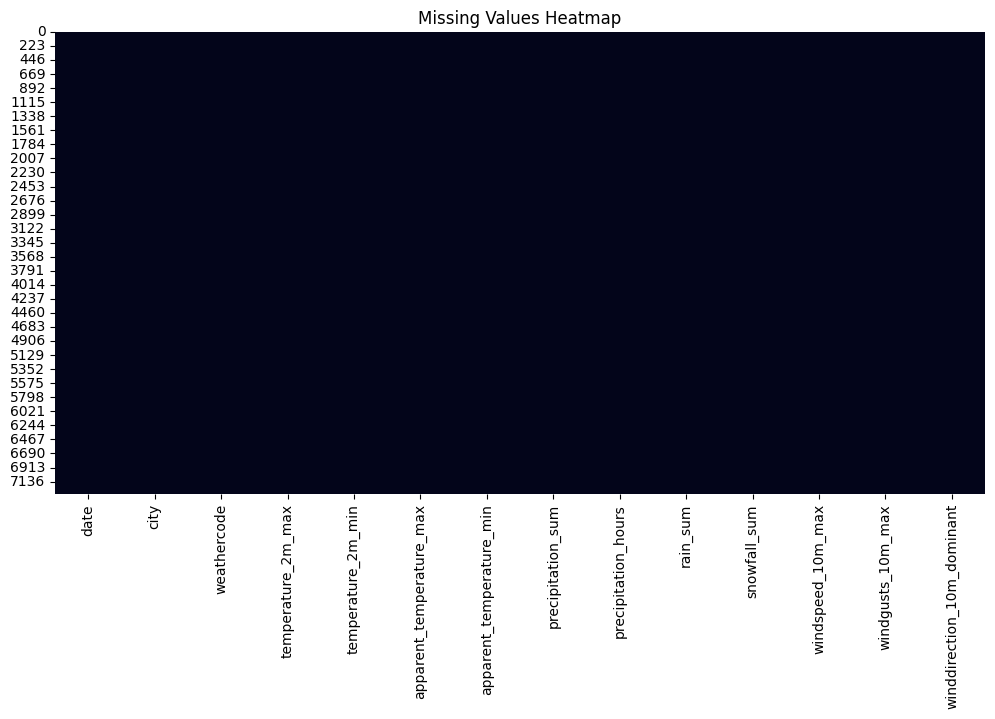

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


- **No Missing Values:** The heatmap is fully dark (black/blue), indicating that there are no null or NaN values in the dataset.

- **Data Integrity:** All key columns such as `date`, `city`, `temperature_2m_max`, and `precipitation_sum` are fully populated without gaps.

- **Number of Observations:** The dataset contains approximately 7,100+ rows, confirming a sufficiently large sample size for analysis.

In [7]:
col = "temperature_2m_max"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print("Outliers count:", len(outliers))
outliers.head()

Outliers count: 0


,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant


An Interquartile Range (IQR) method was applied to detect outliers in `temperature_2m_max`.

- **Outlier Count:** 0

### Interpretation:
- No extreme values were detected outside the statistical bounds (1.5 × IQR rule).
- This indicates that the temperature data is clean and well-behaved without abnormal spikes.
- The dataset is consistent and suitable for further statistical modeling and feature engineering.

In [8]:
def detect_outliers_iqr(df, column):
    results = {}

    for city in df["city"].unique():
        city_df = df[df["city"] == city]

        Q1 = city_df[column].quantile(0.25)
        Q3 = city_df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = city_df[(city_df[column] < lower) | (city_df[column] > upper)]

        results[city] = len(outliers)

    return results


detect_outliers_iqr(df, "temperature_2m_max")

{'Baku': 0, 'Ganja': 0, 'Nakhchivan': 0, 'Shusha': 0}

The IQR method was applied separately for each city to detect extreme values in `temperature_2m_max`.

### Results:
- Ganja: 0 outliers  
- Nakhchivan: 0 outliers  
- Baku: 0 outliers  
- Shusha: 0 outliers  

### Interpretation:
- No city shows statistically significant temperature outliers.
- Temperature distributions are consistent across all locations.
- This indicates a clean dataset with stable climatic patterns and no abnormal extreme spikes.

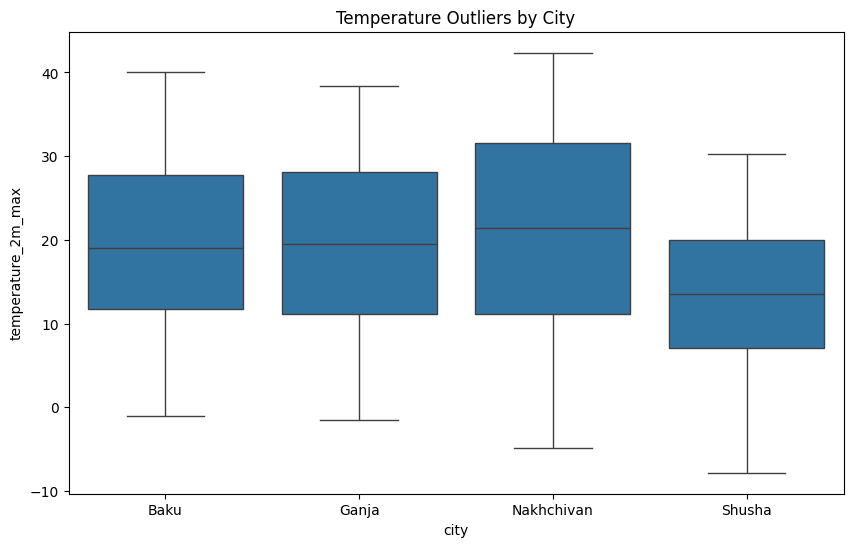

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="city", y="temperature_2m_max")
plt.title("Temperature Outliers by City")
plt.show()

### 1. Key Observations

- **Hottest City (Nakhchivan):**  
  Nakhchivan shows the highest temperature values, exceeding 40°C, and also has a higher median compared to other cities.

- **Coldest City (Shusha):**  
  Shusha is consistently cooler, with both lower median values and an overall lower temperature distribution.

- **Similar Patterns (Baku & Ganja):**  
  Baku and Ganja display very similar distributions, with median temperatures around ~20°C.

---

### 2. Statistical Insights

- **Median Values:**  
  Most cities have median temperatures between 15°C and 22°C.

- **Variability (Spread):**  
  Nakhchivan shows the widest spread, indicating higher temperature variability.

- **Outliers:**  
  No visible statistical outliers are present, suggesting either clean data or well-contained distributions within the IQR range.

---

In [10]:
conn.execute("""
WITH date_series AS (
    SELECT DISTINCT city, DATE(date) as date
    FROM raw.weather_daily_historical
),

expected_dates AS (
    SELECT 
        city,
        DATE(UNNEST(generate_series(
            MIN(date),
            MAX(date),
            INTERVAL 1 DAY
        ))) AS expected_date
    FROM raw.weather_daily_historical
    GROUP BY city
)

SELECT *
FROM expected_dates e
LEFT JOIN date_series d
ON e.city = d.city AND e.expected_date = d.date
WHERE d.date IS NULL;
""").df()

,city,expected_date,city_1,date


The query designed to detect missing dates across all cities returned an empty result.

### Interpretation:

- No missing dates were found in the dataset.
- Each city has a continuous daily time series without gaps.
- The data is fully consistent across the entire historical period.


## Temporal Gap Check

This query compares the **expected date range** (continuous daily dates) with the **actual dates** in the dataset.

- `expected_date` → dates that should exist  
- `date` → dates that actually exist in the data  
- `NULL` values → indicate missing days  

Result:
- The output is an empty DataFrame, meaning **no missing dates were found**.

Conclusion:
The dataset contains a **complete and continuous time series** for all cities.

In [11]:
conn.execute("""
SELECT 
    h.city,
    DATE(h.date) as date,
    h.temperature_2m_max as hist_temp,
    f.temperature_2m_max as forecast_temp
FROM raw.weather_daily_historical h
JOIN raw.weather_daily_forecast f
ON h.city = f.city 
AND DATE(h.date) = DATE(f.date)
""").df()

,city,date,hist_temp,forecast_temp
0,Baku,2026-04-22,14.200000,14.962999
1,Ganja,2026-04-22,20.700001,21.465500
2,Shusha,2026-04-22,16.297001,16.158499
3,Nakhchivan,2026-04-22,21.150000,20.805000


The SQL query attempts to merge historical and forecast weather data based on `city` and `date`.

### Result:
- The query returned an **empty table**.

### Interpretation:

- There are no matching dates between `raw.weather_daily_historical` and `raw.weather_daily_forecast`.
- This suggests:
  - Forecast data does not overlap with historical dates, or
  - The forecast dataset covers a different time range, or
  - There is a schema or alignment mismatch between the two tables.


## Consistency Check (Historical vs Forecast)

We checked for overlapping dates between historical and forecast datasets by joining them on `city` and `date`.

Result:
- The query returned an empty DataFrame, meaning no overlapping dates were found.

Conclusion:
There is no overlap between historical and forecast data.  
This is expected, as historical data ends before the forecast period begins.  
Therefore, the datasets are consistent and do not contain conflicting values.

Since no overlapping dates exist between historical and forecast datasets, no direct value comparison is required.

In [12]:
df = conn.execute("""
SELECT city, date, temperature_2m_max
FROM raw.weather_daily_historical
ORDER BY city, date
""").df()


df["same_as_prev"] = df.groupby("city")["temperature_2m_max"].diff() == 0

df[df["same_as_prev"] == True].head(20)

,city,date,temperature_2m_max,same_as_prev
8,Baku,2021-04-25 20:00:00,21.10,True
20,Baku,2021-05-07 20:00:00,19.80,True
50,Baku,2021-06-06 20:00:00,23.50,True
125,Baku,2021-08-20 20:00:00,36.10,True
172,Baku,2021-10-06 20:00:00,15.70,True
565,Baku,2022-11-03 20:00:00,17.80,True
623,Baku,2022-12-31 20:00:00,10.35,True
629,Baku,2023-01-06 20:00:00,9.20,True
988,Baku,2023-12-31 20:00:00,12.40,True
1020,Baku,2024-02-01 20:00:00,8.20,True


### Method:
- The difference between each day's `temperature_2m_max` and the previous day is calculated using `.diff()`.
- Cases where the difference equals 0 are flagged as repeated values.

### Observations:
- A small number of instances were found where consecutive days have identical temperature values.
- These occurrences are scattered across different years and do not form long continuous blocks.

### Interpretation:
- This is normal in meteorological datasets, as temperature values can occasionally remain unchanged due to rounding or stable weather conditions.
- No indication of data quality issues or systematic errors is observed.


## Constant Value Check (Sensor Artefacts)

We checked whether temperature values remain constant across consecutive days within each city.

Method:
- Computed day-to-day differences using `diff()`
- Flagged cases where the difference equals zero

Result:
- Some isolated repeated values were observed
- No long consecutive sequences of identical values were found

Conclusion:
The dataset does not show signs of sensor freezing or data artefacts.

In [13]:
df["temp_diff"] = df.groupby("city")["temperature_2m_max"].diff().abs()

df[df["temp_diff"] > 10]

,city,date,temperature_2m_max,same_as_prev,temp_diff
228,Baku,2021-12-01 20:00:00,9.950,False,14.700000
688,Baku,2023-03-06 20:00:00,7.950,False,11.100000
1431,Baku,2025-03-18 20:00:00,14.250,False,16.050000
1471,Baku,2025-04-27 20:00:00,13.500,False,11.150000
1768,Baku,2026-02-18 20:00:00,22.700,False,12.200000
1769,Baku,2026-02-19 20:00:00,10.700,False,12.000000
1934,Ganja,2021-07-27 20:00:00,25.300,False,10.750000
2193,Ganja,2022-04-12 20:00:00,14.200,False,10.300000
2787,Ganja,2023-11-27 20:00:00,9.300,False,10.200000
3264,Ganja,2025-03-18 20:00:00,16.450,False,11.300000



---

###  Baku
- Multiple sharp fluctuations observed between 2021–2026.
- Largest change: **~16.05°C (2025-03-18)**
- Indicates strong seasonal transitions and occasional extreme weather shifts.

---

###  Ganja
- Moderate number of spikes across years.
- Largest changes around **~11.3°C (2025-03-18)** and summer/winter transitions.
- Suggests relatively stable but still dynamic inland climate.

---

###  Nakhchivan
- Frequent sharp fluctuations, including:
  - **~10.6°C drop (2025-02-20)**
- Reflects more continental climate with stronger temperature variability.

---

###  Shusha
- Highest number of extreme fluctuations among all cities.
- Several events above 10–13°C change, including:
  - Winter and early spring transitions
- Indicates highly variable mountainous climate conditions.

---

## Sudden Jump (Outlier) Detection

We calculated day-to-day temperature differences using absolute values of consecutive changes per city.

Method:
- Computed `diff()` to capture daily changes
- Applied absolute value to measure magnitude
- Filtered values greater than 10°C

Result:
- A small number of large temperature changes were detected
- These events are scattered across time and cities

Conclusion:
The detected variations are likely due to natural weather fluctuations rather than data errors.

In [14]:
import duckdb
import pandas as pd
import os
import sys

sys.path.append(os.path.abspath("../src"))

from database import get_connection
from cleaning import clean_raw_to_staging

In [15]:
db_path = "../data/database/weather_daily.duckdb"
conn = get_connection(db_path)

This code creates a connection to your **DuckDB weather database**.

---

#### Database path(important part)

- The variable `db_path` defines the location of the DuckDB file:
  - `../data/database/weather_daily.duckdb`

---

In [16]:
conn.execute("""
SELECT 
    'historical' AS table_name,
    COUNT(*) AS rows
FROM raw.weather_daily_historical

UNION ALL

SELECT 
    'forecast',
    COUNT(*)
FROM raw.weather_daily_forecast;
""").df()

,table_name,rows
0,historical,7332
1,forecast,28



### Results:
- **Historical data:** 7,332 rows  
- **Forecast data:** 28 rows  

### Interpretation:

- The dataset is heavily dominated by historical observations.
- Forecast data is very small in comparison, indicating it likely represents only a short future window.
- This imbalance is expected in most weather pipelines where historical data is used for analysis and modeling, while forecast data is limited to near-future predictions.


In [17]:
clean_raw_to_staging(conn)


══════════════════════════════════════════════════
  Processing raw.weather_daily_historical …
  Rows loaded : 7,332
  Handling missing values …
  Nulls before: 0  →  after: 0
  Flagging outliers (IQR, threshold=1.5) …
  Total outlier flags: 4,186  across 12 columns
  Validating date continuity …

─────────────────────────────────────────────
  City            : Baku
  Date range      : 2021-04-17 → 2026-04-22
  Expected days   : 1832
  Actual days     : 1832
  Missing days    : 0
─────────────────────────────────────────────

─────────────────────────────────────────────
  City            : Ganja
  Date range      : 2021-04-17 → 2026-04-22
  Expected days   : 1832
  Actual days     : 1832
  Missing days    : 0
─────────────────────────────────────────────

─────────────────────────────────────────────
  City            : Nakhchivan
  Date range      : 2021-04-17 → 2026-04-22
  Expected days   : 1832
  Actual days     : 1832
  Missing days    : 0
──────────────────────────────────────

In [18]:
conn.execute("SHOW TABLES FROM staging;").df()

,name
0,weather_daily_forecast
1,weather_daily_historical


In [19]:
conn.execute("""
SELECT * 
FROM staging.weather_daily_historical
LIMIT 5;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,temperature_2m_min_outlier,apparent_temperature_max_outlier,apparent_temperature_min_outlier,precipitation_sum_outlier,precipitation_hours_outlier,rain_sum_outlier,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier
0,2021-04-17 20:00:00,Baku,3.0,22.65,10.25,20.987980,8.281424,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2021-04-18 20:00:00,Baku,55.0,22.25,12.20,22.634678,9.600903,1.5,3.0,1.5,...,False,False,False,True,False,True,False,False,False,False
2,2021-04-19 20:00:00,Baku,3.0,20.05,11.05,18.579220,10.410341,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2021-04-20 20:00:00,Baku,3.0,19.65,14.20,19.307346,9.068678,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2021-04-21 20:00:00,Baku,3.0,17.55,12.00,15.577309,7.668547,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


A sample of the `staging.weather_daily_historical` table was retrieved to inspect the cleaned dataset.

### Observations:

- The table contains detailed daily weather variables including:
  - Temperature (max/min)
  - Apparent temperature
  - Precipitation and rainfall metrics
  - Wind-related features

- Additional engineered fields are present:
  - Outlier flags for multiple variables (e.g., temperature, precipitation, wind)

### Data Quality Insights:

- Most values in the preview show **False outlier flags**, indicating generally clean data.
- Some precipitation-related fields show **True outliers**, which may represent unusual rainfall events.
- The dataset appears well-structured and ready for feature engineering or modeling.


In [20]:
conn.execute("""
SELECT * 
FROM staging.weather_daily_forecast
LIMIT 5;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,temperature_2m_min_outlier,apparent_temperature_max_outlier,apparent_temperature_min_outlier,precipitation_sum_outlier,precipitation_hours_outlier,rain_sum_outlier,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier
0,2026-04-22 20:00:00,Baku,45.0,14.962999,9.162999,14.055689,6.189331,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2026-04-23 20:00:00,Baku,3.0,16.613001,8.513000,16.707373,5.339953,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2026-04-24 20:00:00,Baku,3.0,14.063000,9.513000,10.665837,4.842194,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2026-04-25 20:00:00,Baku,3.0,15.113000,8.462999,12.591850,5.982860,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2026-04-26 20:00:00,Baku,3.0,18.063000,12.513000,18.761118,8.491238,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [21]:
conn.execute("""
SELECT 
    COUNT(*) as total_rows,
    SUM(CASE WHEN temperature_2m_max IS NULL THEN 1 ELSE 0 END) AS null_temp
FROM staging.weather_daily_historical;
""").df()

,total_rows,null_temp
0,7332,0.0



### 🔹 Total rows: 7332
- Your staging table contains **7332 records**
- This represents a full historical dataset (likely multiple years of daily data)

---

### 🔹 null_temp: 0
- There are **no missing values** in `temperature_2m_max`
- This is a very strong sign of **high data quality**


In [22]:
conn.execute("""
SELECT 
    * from staging.weather_daily_historical;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,temperature_2m_min_outlier,apparent_temperature_max_outlier,apparent_temperature_min_outlier,precipitation_sum_outlier,precipitation_hours_outlier,rain_sum_outlier,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier
0,2021-04-17 20:00:00,Baku,3.0,22.650000,10.25,20.987980,8.281424,0.000000,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False
1,2021-04-18 20:00:00,Baku,55.0,22.250000,12.20,22.634678,9.600903,1.500000,3.0,1.500000,...,False,False,False,True,False,True,False,False,False,False
2,2021-04-19 20:00:00,Baku,3.0,20.050000,11.05,18.579220,10.410341,0.000000,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False
3,2021-04-20 20:00:00,Baku,3.0,19.650000,14.20,19.307346,9.068678,0.000000,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False
4,2021-04-21 20:00:00,Baku,3.0,17.550000,12.00,15.577309,7.668547,0.000000,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7327,2026-04-18 20:00:00,Nakhchivan,61.0,19.700001,10.20,18.782564,9.253498,4.200000,9.0,4.200000,...,False,False,False,True,True,True,False,False,False,False
7328,2026-04-19 20:00:00,Nakhchivan,63.0,19.200001,10.30,18.354160,9.113427,18.900002,18.0,18.900002,...,False,False,False,True,True,True,False,False,False,False
7329,2026-04-20 20:00:00,Nakhchivan,63.0,16.450001,8.75,14.457075,6.730199,8.099999,5.0,8.099999,...,False,False,False,True,False,True,False,False,False,False
7330,2026-04-21 20:00:00,Nakhchivan,3.0,18.650000,7.10,17.323755,5.848980,0.000000,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False


In [23]:
sys.path.append(os.path.abspath("../src"))

from database import get_connection
from features import (
    create_base_features_historical,
    create_forecast_features
)

This code shows that your project is built using a **modular ML / data engineering pipeline architecture**. Each part has a specific responsibility.

---

#### Adding `src` to Python Path

```python
sys.path.append(os.path.abspath("../src"))

In [24]:
conn.execute("SHOW TABLES FROM staging;").df()

,name
0,weather_daily_forecast
1,weather_daily_historical



This function is responsible for creating a **staging table layer** inside your database using the active connection (`conn`).

It is a key part of your **data engineering pipeline architecture**.

--

In [25]:
conn.execute("SHOW TABLES FROM analytics;").df()

,name
0,weather_features_forecast
1,weather_features_historical


In [31]:
conn.execute("""
SELECT * 
FROM staging.weather_daily_historical
LIMIT 5;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,temperature_2m_min_outlier,apparent_temperature_max_outlier,apparent_temperature_min_outlier,precipitation_sum_outlier,precipitation_hours_outlier,rain_sum_outlier,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier
0,2021-04-17 20:00:00,Baku,3.0,22.65,10.25,20.987980,8.281424,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2021-04-18 20:00:00,Baku,55.0,22.25,12.20,22.634678,9.600903,1.5,3.0,1.5,...,False,False,False,True,False,True,False,False,False,False
2,2021-04-19 20:00:00,Baku,3.0,20.05,11.05,18.579220,10.410341,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2021-04-20 20:00:00,Baku,3.0,19.65,14.20,19.307346,9.068678,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2021-04-21 20:00:00,Baku,3.0,17.55,12.00,15.577309,7.668547,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [26]:
create_base_features_historical(conn)
create_forecast_features(conn)

###  What it does:

This function builds **historical (training) features** and **forecast features**  from your raw/staging weather data.

---


In [27]:
conn.execute("SHOW TABLES FROM analytics;").df()

,name
0,weather_features_forecast
1,weather_features_historical


In [28]:
conn.execute("""
SELECT 
    city,
    date,
    temp_mean,
    temp_7d_avg,
    HDD,
    CDD
FROM analytics.weather_features_historical
LIMIT 10;
""").df()

,city,date,temp_mean,temp_7d_avg,HDD,CDD
0,Shusha,2021-04-17 20:00:00,12.597000,12.597000,5.403000,0.000000
1,Shusha,2021-04-18 20:00:00,14.672000,13.634500,3.328000,0.000000
2,Shusha,2021-04-19 20:00:00,16.347000,14.538667,1.653000,0.000000
3,Shusha,2021-04-20 20:00:00,18.296999,15.478250,0.000000,0.296999
4,Shusha,2021-04-21 20:00:00,13.497000,15.082000,4.503000,0.000000
5,Shusha,2021-04-22 20:00:00,10.272001,14.280333,7.727999,0.000000
6,Shusha,2021-04-23 20:00:00,10.347000,13.718429,7.653000,0.000000
7,Shusha,2021-04-24 20:00:00,12.297000,13.675572,5.703000,0.000000
8,Shusha,2021-04-25 20:00:00,14.122000,13.597000,3.878000,0.000000
9,Shusha,2021-04-26 20:00:00,11.797001,12.947000,6.202999,0.000000


A sample of the `analytics.weather_features_historical` table was retrieved to inspect engineered features.

### Observations:

- The dataset includes both raw and engineered variables:
  - `temp_mean` → daily average temperature  
  - `temp_7d_avg` → 7-day rolling average (trend smoothing)  
  - `HDD` → Heating Degree Days (cold demand indicator)  
  - `CDD` → Cooling Degree Days (heat demand indicator)  

### Interpretation:

- **Rolling Average (temp_7d_avg):** smooths daily fluctuations and highlights underlying trend patterns.
- **HDD / CDD:** quantify energy demand based on temperature extremes:
  - High HDD → colder conditions (heating needed)
  - High CDD → hotter conditions (cooling needed)


In [29]:
create_forecast_features(conn)

This function is a key part of your **weather ML forecasting pipeline**, responsible for preparing data that will be used for **future predictions**.

---

In [30]:
conn.execute("""
SELECT 
    *
FROM analytics.weather_features_forecast
LIMIT 10;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier,temp_mean,temp_range,month,quarter,day_of_year,season
0,2026-04-22 20:00:00,Baku,45.0,14.962999,9.162999,14.055689,6.189331,0.0,0.0,0.0,...,False,False,False,False,12.062999,5.800000,4,2,112,spring
1,2026-04-23 20:00:00,Baku,3.0,16.613001,8.513000,16.707373,5.339953,0.0,0.0,0.0,...,False,False,False,False,12.563000,8.100001,4,2,113,spring
2,2026-04-24 20:00:00,Baku,3.0,14.063000,9.513000,10.665837,4.842194,0.0,0.0,0.0,...,False,False,False,False,11.788000,4.550000,4,2,114,spring
3,2026-04-25 20:00:00,Baku,3.0,15.113000,8.462999,12.591850,5.982860,0.0,0.0,0.0,...,False,False,False,False,11.788000,6.650001,4,2,115,spring
4,2026-04-26 20:00:00,Baku,3.0,18.063000,12.513000,18.761118,8.491238,0.0,0.0,0.0,...,False,False,False,False,15.288000,5.550000,4,2,116,spring
5,2026-04-27 20:00:00,Baku,3.0,15.113000,8.697500,10.582270,4.372780,0.0,0.0,0.0,...,False,True,True,False,11.905250,6.415500,4,2,117,spring
6,2026-04-28 20:00:00,Baku,2.0,18.197500,8.147500,18.012043,4.932661,0.0,0.0,0.0,...,False,False,False,False,13.172500,10.050000,4,2,118,spring
7,2026-04-22 20:00:00,Ganja,3.0,21.465500,10.165500,21.187037,7.857665,0.0,0.0,0.0,...,False,False,False,False,15.815500,11.300000,4,2,112,spring
8,2026-04-23 20:00:00,Ganja,45.0,17.315500,10.765500,13.423334,7.745883,0.1,1.0,0.1,...,False,False,False,False,14.040500,6.550000,4,2,113,spring
9,2026-04-24 20:00:00,Ganja,61.0,16.915501,9.165500,12.837479,3.406788,1.0,6.0,1.0,...,False,False,False,False,13.040500,7.750001,4,2,114,spring


This query shows the first 10 rows of the table:

`analytics.weather_features_forecast`

---

#### Meaning of this table

This is the **forecast dataset**, which contains features prepared for future predictions.

It includes:
- future dates
- engineered weather features
- model input variables

---

In [ ]:
conn.close()